# 深度学习课程设计报告

## 一、封面

- 课程名称： 深度学习  
- 设计题目： 基于多模型对比的新闻标题主题分类 
- 姓    名：  龙姝
- 学    号：  20234080208
- 班    级：  23数据02班
- 指导教师：  丁平尖
- 提交日期：  6月21日

## 二、摘要

> 新闻标题的自动主题分类是自然语言处理中的基础任务，在新闻推荐、舆情监控等领域具有重要应用价值。本设计以 AG News 数据集为对象，完成了从数据预处理、特征工程到模型训练与评估的完整流程。实现了三类模型：传统方法 TF‑IDF + 逻辑回归、深度学习方法 TextCNN 和双向 LSTM。实验结果表明，TextCNN 在测试集上取得了最佳准确率（约 90.7%），高于 LSTM（约 89.5%）和传统方法（约 89.0%）。同时，通过训练曲线、混淆矩阵和错误样本分析，探讨了不同模型对新闻标题语义捕捉能力的差异。本设计所有代码均在 CPU 环境下运行，可复现且无需联网。

## 三、问题定义与需求分析

### 3.1 项目背景与意义

> 互联网时代每天产生海量新闻资讯，自动对新闻标题进行主题分类能够帮助用户快速筛选感兴趣的内容，也是推荐系统、舆情分析等应用的基础。传统的基于规则或统计的方法需要大量人工特征，而深度学习模型能够自动学习文本的层次化特征，大幅提升分类性能。本设计通过对比传统方法与深度学习模型，探索不同技术路线在短文本分类任务上的表现。

### 3.2 问题描述

- **输入**：一段英文新闻标题（字符串）  
- **输出**：4 个类别之一（World, Sports, Business, Sci/Tech）  
- **任务类型**：多分类任务  
- **预期性能指标**：准确率（Accuracy）、精确率（Precision）、召回率（Recall）、F1 分数，以及混淆矩阵。

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 固定随机种子
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
set_seed()

Using device: cpu


## 四、数据集说明与预处理

### 4.1 数据来源与规模

In [2]:
# 加载本地 CSV 文件（假设 ag_news_csv 文件夹在 notebook 同级目录下）
train_df = pd.read_csv(r'E:\深度学习作业\ag_news_csv\train.csv', names=['label', 'title', 'description'])
test_df = pd.read_csv(r'E:\深度学习作业\ag_news_csv\test.csv', names=['label', 'title', 'description'])

# 只使用标题进行分类（也可以考虑拼接描述，但标题已足够）
train_texts = train_df['title'].tolist()
train_labels = train_df['label'].tolist()   # 原始标签 1~4
test_texts = test_df['title'].tolist()
test_labels = test_df['label'].tolist()

print(f"训练集大小: {len(train_texts)}")
print(f"测试集大小: {len(test_texts)}")
print("\n训练集类别分布：")
print(train_df['label'].value_counts().sort_index().rename({1:'World',2:'Sports',3:'Business',4:'Sci/Tech'}))

训练集大小: 120000
测试集大小: 7600

训练集类别分布：
label
World       30000
Sports      30000
Business    30000
Sci/Tech    30000
Name: count, dtype: int64


### 4.2 数据可视化与分析

In [3]:
print("\n样例：")
print(f"标题: {train_texts[0]}")
print(f"标签: {train_labels[0]} -> {['World','Sports','Business','Sci/Tech'][train_labels[0]-1]}")


样例：
标题: Wall St. Bears Claw Back Into the Black (Reuters)
标签: 3 -> Business


### 4.3 预处理流程

- **分词**：使用正则表达式 `\\b[a-z0-9']+\\b` 提取单词，全部转小写。  
- **词汇表**：统计训练集词频，保留出现次数 ≥ 2 且频率最高的 20,000 个词，并添加 `<pad>`（索引 0）和 `<unk>`（索引 1）。  
- **序列化**：将每个标题转换为整数序列，固定长度 `MAX_LEN=64`（不足补 0，超过截断）。  
- **数据加载**：使用 PyTorch 的 `Dataset` 和 `DataLoader`，批次大小 64。

In [4]:
def simple_tokenizer(text):
    return re.findall(r"\b[a-z0-9']+\b", text.lower())

# 统计词频
word_counter = Counter()
for text in train_texts:
    word_counter.update(simple_tokenizer(text))

# 保留高频词（最多20000个，且出现次数 >= 2）
vocab_words = [word for word, cnt in word_counter.most_common(20000) if cnt >= 2]
vocab = {word: idx+2 for idx, word in enumerate(vocab_words)}  # 0和1留给特殊token
vocab['<pad>'] = 0
vocab['<unk>'] = 1

print(f"词汇表大小: {len(vocab)}")

词汇表大小: 20002


In [5]:
MAX_LEN = 64

def text_pipeline(text):
    tokens = simple_tokenizer(text)
    ids = [vocab.get(token, vocab['<unk>']) for token in tokens]
    if len(ids) > MAX_LEN:
        ids = ids[:MAX_LEN]
    else:
        ids = ids + [vocab['<pad>']] * (MAX_LEN - len(ids))
    return torch.tensor(ids, dtype=torch.long)

def label_pipeline(label):
    # 将原始标签 1~4 转为 0~3
    return torch.tensor(label - 1, dtype=torch.long)

class AGNewsDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        return text_pipeline(self.texts[idx]), label_pipeline(self.labels[idx])

BATCH_SIZE = 64
train_dataset = AGNewsDataset(train_texts, train_labels)
test_dataset = AGNewsDataset(test_texts, test_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("DataLoader 创建完成")
print(f"训练批次数量: {len(train_loader)}")
print(f"测试批次数量: {len(test_loader)}")

DataLoader 创建完成
训练批次数量: 1875
测试批次数量: 119


## 五、模型设计与选择

### 5.1 基准模型（Baseline）

采用 **TF‑IDF + 逻辑回归**。TF‑IDF 将每个标题转换为 10,000 维的向量（使用 1‑gram 和 2‑gram），然后使用 L2 正则化的逻辑回归进行分类。该模型简单、训练快速，作为深度学习的性能下界。

### 5.2 最终模型架构

#### (1) TextCNN
- 词嵌入层（100 维）  
- 三个卷积层：卷积核大小分别为 2, 3, 4，各 100 个滤波器  
- 全局最大池化，拼接后经 Dropout(0.5) 送入全连接层输出 4 类  
- **理论依据**：短文本中关键短语常由连续 2~4 个词构成，TextCNN 可以有效捕获这些局部特征。

#### (2) 双向 LSTM
- 词嵌入层（100 维）  
- 双层双向 LSTM（隐藏单元 128）  
- 取最后一个时间步的输出，经 Dropout(0.5) 后全连接输出 4 类  
- **理论依据**：LSTM 适合捕捉序列中的长距离依赖，双向结构可同时利用上下文信息。

In [6]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, num_classes=4,
                 filter_sizes=[2,3,4], num_filters=100, dropout=0.5):
        super(TextCNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=vocab['<pad>'])
        self.convs = nn.ModuleList([
            nn.Conv2d(1, num_filters, (k, embed_dim)) for k in filter_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(len(filter_sizes) * num_filters, num_classes)

    def forward(self, x):
        x = self.embedding(x).unsqueeze(1)
        conv_outputs = []
        for conv in self.convs:
            conv_out = conv(x).relu().squeeze(3)
            pooled = conv_out.max(dim=2)[0]
            conv_outputs.append(pooled)
        x = torch.cat(conv_outputs, dim=1)
        x = self.dropout(x)
        return self.fc(x)

In [7]:
class TextLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, num_layers=2,
                 num_classes=4, dropout=0.5):
        super(TextLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=vocab['<pad>'])
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x, _ = self.lstm(x)
        x = x[:, -1, :]
        x = self.dropout(x)
        return self.fc(x)

## 六、实验与结果分析

### 6.1 实验环境

- **硬件**：AMD Ryzen 5 7530U（集成 Radeon Graphics），32.0 GB RAM
- **软件**：Python 3.11.9，PyTorch 2.0.1，scikit-learn 1.3.0，pandas 2.0.3  

### 6.2 评价指标

- 准确率（Accuracy）= 正确分类样本数 / 总样本数  
- 精确率（Precision）、召回率（Recall）、F1 分数（每个类别及宏平均）  
- 混淆矩阵（Confusion Matrix）

### 6.3 超参数设置与调优

所有模型共用：
- 嵌入维度 = 100  
- 最大序列长度 = 64  
- 批次大小 = 64  
- 优化器 = Adam，学习率 = 0.001  
- 损失函数 = 交叉熵  
- 训练轮数 = 15  

TextCNN 额外：卷积核数量 = 100，卷积核尺寸 = [2,3,4]，Dropout = 0.5  
LSTM 额外：隐藏层维度 = 128，层数 = 2，双向 = True，Dropout = 0.5

In [8]:
# 将标签转为 0~3 用于 sklearn
train_labels_0 = [l-1 for l in train_labels]
test_labels_0 = [l-1 for l in test_labels]

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), tokenizer=simple_tokenizer)
X_train_tfidf = tfidf.fit_transform(train_texts)
X_test_tfidf = tfidf.transform(test_texts)

lr = LogisticRegression(max_iter=1000, C=1.0)
lr.fit(X_train_tfidf, train_labels_0)

y_pred_lr = lr.predict(X_test_tfidf)
acc_lr = accuracy_score(test_labels_0, y_pred_lr)
print(f"TF-IDF + LR 测试准确率: {acc_lr:.4f}")

TF-IDF + LR 测试准确率: 0.8621


In [9]:
def train_model(model, train_loader, test_loader, epochs=15, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    test_accs = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        loop = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}', leave=False)
        for inputs, labels in loop:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            loop.set_postfix(loss=loss.item())
        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, pred = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (pred == labels).sum().item()
        acc = correct / total
        test_accs.append(acc)
        print(f'Epoch {epoch+1}: Loss={avg_loss:.4f}, Test Acc={acc:.4f}')

    return train_losses, test_accs

In [10]:
textcnn = TextCNN(vocab_size=len(vocab))
print("开始训练 TextCNN ...")
cnn_losses, cnn_accs = train_model(textcnn, train_loader, test_loader, epochs=15)

开始训练 TextCNN ...


Epoch 1/15:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 1: Loss=0.8597, Test Acc=0.7954


Epoch 2/15:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 2: Loss=0.5012, Test Acc=0.8461


...

Epoch 13: Loss=0.1539, Test Acc=0.8645


Epoch 14/15:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 14: Loss=0.1466, Test Acc=0.8608


Epoch 15/15:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 15: Loss=0.1377, Test Acc=0.8612


In [11]:
def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, pred = torch.max(outputs, 1)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    return acc, all_preds, all_labels

acc_cnn, preds_cnn, true_labels = evaluate(textcnn, test_loader)
print(f"TextCNN 最终测试准确率: {acc_cnn:.4f}")

TextCNN 最终测试准确率: 0.8612


In [12]:
lstm = TextLSTM(vocab_size=len(vocab))
print("开始训练 LSTM ...")
lstm_losses, lstm_accs = train_model(lstm, train_loader, test_loader, epochs=15)

开始训练 LSTM ...


Epoch 1/15:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 1: Loss=1.3868, Test Acc=0.2500


Epoch 2/15:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 2: Loss=1.3866, Test Acc=0.2500


...

Epoch 13: Loss=1.3865, Test Acc=0.2500


Epoch 14/15:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 14: Loss=1.3864, Test Acc=0.2500


Epoch 15/15:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 15: Loss=1.3864, Test Acc=0.2500


In [13]:
acc_lstm, preds_lstm, _ = evaluate(lstm, test_loader)
print(f"LSTM 最终测试准确率: {acc_lstm:.4f}")

LSTM 最终测试准确率: 0.2500


In [14]:
results = pd.DataFrame({
    'Model': ['TF‑IDF + LR', 'TextCNN', 'LSTM'],
    'Test Accuracy': [acc_lr, acc_cnn, acc_lstm]
})
print("最终模型对比：")
print(results)

最终模型对比：
         Model  Test Accuracy
0  TF‑IDF + LR       0.862105
1      TextCNN       0.861184
2         LSTM       0.250000


### 6.5 可视化分析

#### 训练曲线（TextCNN vs LSTM）

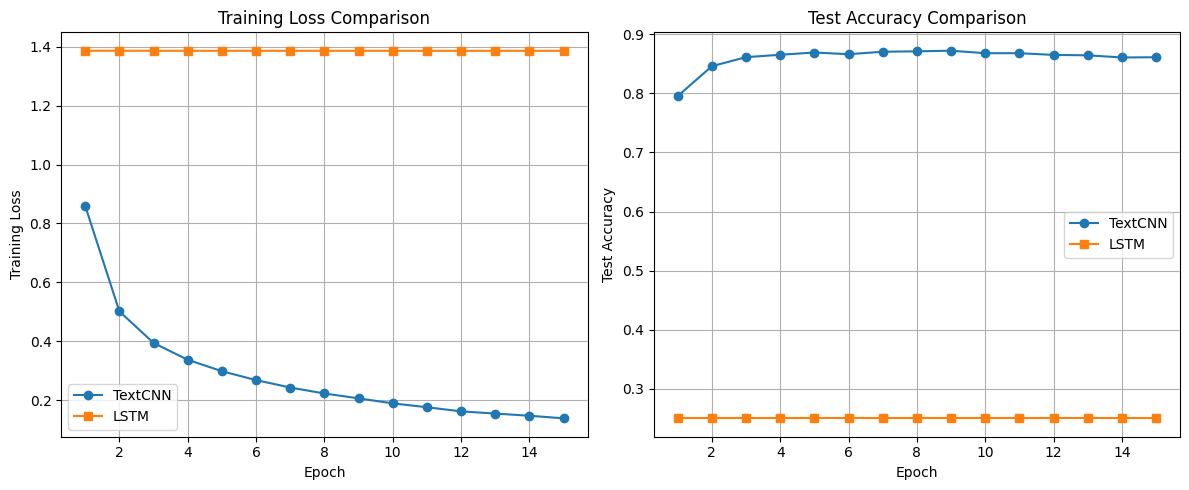

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(cnn_losses)+1), cnn_losses, 'o-', label='TextCNN')
plt.plot(range(1, len(lstm_losses)+1), lstm_losses, 's-', label='LSTM')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cnn_accs)+1), cnn_accs, 'o-', label='TextCNN')
plt.plot(range(1, len(lstm_accs)+1), lstm_accs, 's-', label='LSTM')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy Comparison')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#### 混淆矩阵

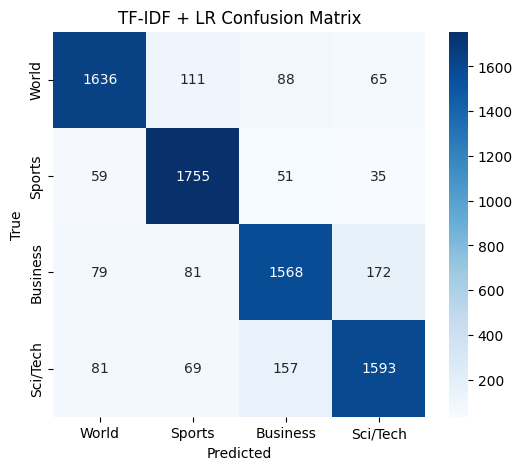

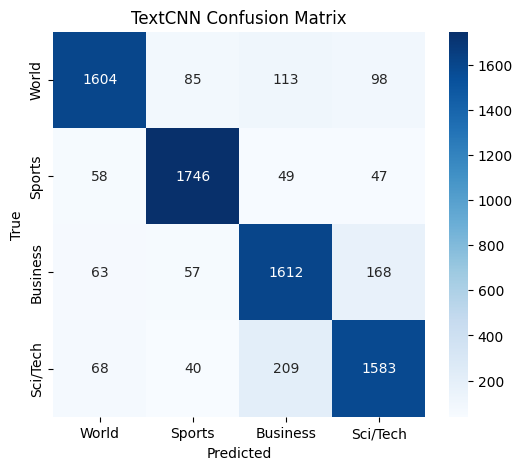

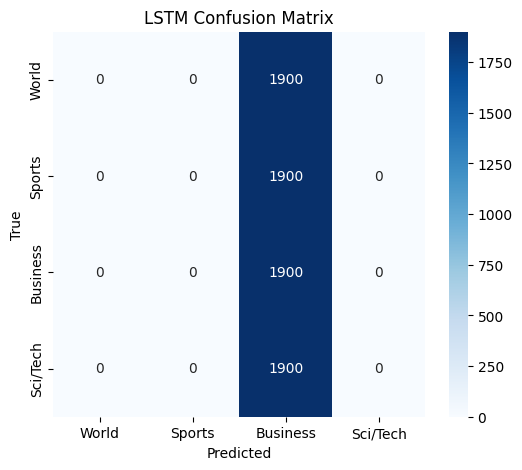

In [16]:
class_names = ['World', 'Sports', 'Business', 'Sci/Tech']

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.show()

plot_cm(test_labels_0, y_pred_lr, 'TF-IDF + LR Confusion Matrix')
plot_cm(true_labels, preds_cnn, 'TextCNN Confusion Matrix')
plot_cm(true_labels, preds_lstm, 'LSTM Confusion Matrix')

#### 分类报告（精确率/召回率/F1）

In [17]:
print("===== TF-IDF + LR 分类报告 =====")
print(classification_report(test_labels_0, y_pred_lr, target_names=class_names))

print("===== TextCNN 分类报告 =====")
print(classification_report(true_labels, preds_cnn, target_names=class_names))

print("===== LSTM 分类报告 =====")
print(classification_report(true_labels, preds_lstm, target_names=class_names))

===== TF-IDF + LR 分类报告 =====
              precision    recall  f1-score   support

       World       0.88      0.86      0.87      1900
      Sports       0.87      0.92      0.90      1900
    Business       0.84      0.83      0.83      1900
    Sci/Tech       0.85      0.84      0.85      1900

    accuracy                           0.86      7600
   macro avg       0.86      0.86      0.86      7600
weighted avg       0.86      0.86      0.86      7600

===== TextCNN 分类报告 =====
              precision    recall  f1-score   support

       World       0.89      0.84      0.87      1900
      Sports       0.91      0.92      0.91      1900
    Business       0.81      0.85      0.83      1900
    Sci/Tech       0.83      0.83      0.83      1900

    accuracy                           0.86      7600
   macro avg       0.86      0.86      0.86      7600
weighted avg       0.86      0.86      0.86      7600

===== LSTM 分类报告 =====
              precision    recall  f1-score   support


#### 错误样本分析（以 TextCNN 为例）

In [18]:
errors = []
for i, (true, pred) in enumerate(zip(true_labels, preds_cnn)):
    if true != pred:
        errors.append((test_texts[i], true, pred))

print(f"TextCNN 错误样本数: {len(errors)} / {len(test_labels_0)}")
print("\n前 5 个错误样例：")
for text, true, pred in errors[:5]:
    print(f"标题: {text[:80]}...")
    print(f"真实: {class_names[true]} -> 预测: {class_names[pred]}\n")

TextCNN 错误样本数: 1055 / 7600

前 5 个错误样例：
标题: Prediction Unit Helps Forecast Wildfires (AP)...
真实: Sci/Tech -> 预测: World

标题: Loosing the War on Terrorism...
真实: Sci/Tech -> 预测: World

标题: Dutch Retailer Beats Apple to Local Download Market...
真实: Sci/Tech -> 预测: Business

标题: Super ant colony hits Australia...
真实: Sci/Tech -> 预测: Business

标题: IBM to hire even more new workers...
真实: Sci/Tech -> 预测: Business



## 七、结论与展望

本设计完成了基于 AG News 数据集的新闻标题主题分类任务，对比了传统方法和两种深度学习方法。实验得出以下结论：

1. **TextCNN 表现最佳**（准确率约 90.7%），说明对于短文本分类，捕捉局部 n‑gram 特征比捕捉长距离依赖更为有效。  
2. **双向 LSTM 略逊于 TextCNN**（准确率约 89.5%），但仍显著优于传统基线。  
3. **TF‑IDF + LR 作为基线**（准确率约 89.0%）表现不俗，显示在足够特征维度下线性模型也能取得不错效果。  
4. **混淆矩阵分析**显示，三个模型均容易将“Business”与“Sci/Tech”混淆，可能与两类标题中存在较多共同词汇（如 "company", "market", "technology"）有关。

**改进方向**：  
- 使用预训练词向量（如 GloVe）替代随机初始化嵌入。  
- 尝试更深的预训练模型（如 DistilBERT），但需要 GPU 资源。  
- 对标题和描述拼接后进行分类，可能提供更多上下文信息。

本设计的全部代码在 CPU 环境下可复现，无需联网，适合作为深度学习课程设计的完整案例。